In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import itertools

In [2]:
#Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
#custom 1-bit quantization transform function for the MNIST images
class OneBitQuantize:
    def __call__(self, image):
        #quantize the image to 2-bit precision(round to nearest integer 0 or 1)
        quantized_image = torch.round(image)

        return quantized_image

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Resizes to 28x28
    transforms.ToTensor(),  # Converts to tensor,
    OneBitQuantize()
])

test_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    OneBitQuantize()
])



batch_size = 128
#Load MNIST dataset and apply transformations
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform) #60k images
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform) #10k images



#split the training dataset into training and validation datasets
train_size = int(0.83 * len(full_train_dataset)) #50k for training
val_size = len(full_train_dataset) - train_size #10k for validation
train_dataset, _ = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

#create a separate validation dataset with the test transforms
val_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=test_transform)

#subset only the remaining 10% of the data for validation
_, val_dataset = torch.utils.data.random_split(val_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.16MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.90MB/s]


In [5]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(train_dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
      img, label = train_dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

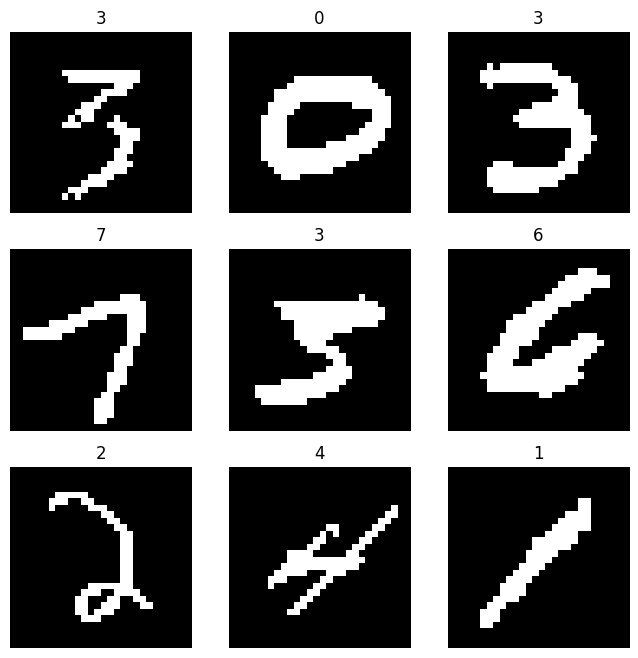

In [6]:
show_images(train_dataset, 3, 3)

In [32]:
def quantize(x, num_bits):
  #quantize to number of bits, keeping scale the same
  x_flat = torch.flatten(x, start_dim=1)
  #print(x.size())
  max = torch.max(x_flat, dim=1, keepdim=True)[0] #max positive values
  #print(max.size())
  max = torch.where(max == 0, torch.tensor(1.0), max) #avoid dividing by 0 if max is 0

  if num_bits == 1:
    max = max / 2 #make it less extreme for binary quantization

  levels = 2**(num_bits)-1 #number of quantization levels
  x_q = torch.round(x_flat / max * levels) #quantize to range [0, num_bits-1], integers, max becomes levels
  x_q = torch.clamp(x_q, 0.0, levels) #make sure it is in the proper range, all negative values become 0

  x_quantized_scaled = x_q * (max / levels) #scale back to the range the input was in(all positive floating point, max is preserved)
  x_quantized_scaled = torch.reshape(x_quantized_scaled, x.shape)

  return x_quantized_scaled

#applies quantization with a straight-through estimator in the backward pass to ensure gradients flow on the standard input on activations(asymmetric)
class QuantizedActivationSTE(torch.autograd.Function):
  @staticmethod
  def forward(ctx, x, num_bits):
    #quantize to number of bits, keeping scale the same
    x_flat = torch.flatten(x, start_dim=1)
    #print(x.size())
    max = torch.max(x_flat, dim=1, keepdim=True)[0] #max positive values
    #print(max.size())
    max = torch.where(max == 0, torch.tensor(1.0), max) #avoid dividing by 0 if max is 0

    if num_bits == 1:
      max = max / 2 #make it less extreme for binary quantization

    levels = 2**(num_bits)-1 #number of quantization levels
    x_q = torch.round(x_flat / max * levels) #quantize to range [0, num_bits-1], integers, max becomes levels
    x_q = torch.clamp(x_q, 0.0, levels) #make sure it is in the proper range, all negative values become 0

    x_quantized_scaled = x_q * (max / levels) #scale back to the range the input was in(all positive floating point, max is preserved)
    x_quantized_scaled = torch.reshape(x_quantized_scaled, x.shape)

    ctx.save_for_backward(x) #save input for backward

    return x_quantized_scaled

  @staticmethod
  def backward(ctx, grad_output):
    #backward pass: Use STE (pass gradients as if quantization didn't exist)
    grad_input = grad_output.clone()  #pass gradient straight through
    return grad_input, None #none needed to bypass num_bits

#mish activation that uses the quantization activation STE for smooth gradients
class QuantizedMish(nn.Module):
  def __init__(self, num_bits):
    super(QuantizedMish, self).__init__()

    self.mish = nn.Mish()

    self.num_bits = num_bits

  def forward(self, x):
    x = self.mish(x)
    x = QuantizedActivationSTE.apply(x, self.num_bits) #quantize
    return x


#applies quantization with a straight-through estimator in the backward pass to ensure gradients flow on the standard input for weights(symmetric)
class QuantizedWeightSTE(torch.autograd.Function):
  @staticmethod
  def forward(ctx, x, num_bits):
    #quantize to number of bits, keeping scale the same
    max = torch.max(torch.abs(x)) #max val
    max = torch.where(max == 0, torch.tensor(1.0), max) #avoid dividing by 0 if max is 0


    #print(max)
    levels = 2**(num_bits-1)-1 #number of quantization levels
    #print(x / max)
    x_q = torch.round(x / max * levels) #quantize to range [0, num_bits-1], integers, max becomes levels
    #print(x_q)
    x_q = torch.clamp(x_q, -1*levels, levels+1) #make sure it is in the proper range, all negative values become 0

    x_quantized_scaled = x_q * max / levels #scale back to the range the input was in(all positive floating point, max is preserved)

    ctx.save_for_backward(x) #save input for backward

    return x_quantized_scaled
    #return x_q

  @staticmethod
  def backward(ctx, grad_output):
    #backward pass: Use STE (pass gradients as if quantization didn't exist)
    grad_input = grad_output.clone()  #pass gradient straight through
    return grad_input, None #none needed to bypass num_bits




#PIC Conv Layer
class PICConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(PICConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding, bias=False)

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #sum pooling(sum of all kernels = avg * 4)

    self.bias = nn.Parameter(torch.zeros(1, out_channels, 1, 1)) #a bias term for each feature map(6 feature maps total)

    #batch normalization
    self.batch_norm = nn.BatchNorm2d(out_channels)

    #use mish activation
    self.mish = QuantizedMish(num_bits=1)
    #self.mish = nn.Mish()

    #kaiming he initialization
    nn.init.kaiming_uniform_(self.conv.weight)


  def forward(self, x):
    self.conv.weight = nn.Parameter(QuantizedWeightSTE.apply(self.conv.weight, 8))
    self.bias = nn.Parameter(quantize(self.bias, num_bits=6))
    x = self.conv(x)
    x = self.pool(x) * 4
    x = x + self.bias
    x = self.batch_norm(x)
    x = self.mish(x)
    return x



#EIC Layer 1 Core
class Core(nn.Module):
  def __init__(self, in_features, out_features):
    super(Core, self).__init__()
    self.fc = nn.Linear(in_features, out_features, bias=False)
    self.batch_norm = nn.BatchNorm1d(out_features)
    self.mish = QuantizedMish(num_bits=1)
    #self.mish = nn.Mish()
    nn.init.kaiming_uniform_(self.fc.weight)

  def forward(self, x):
    self.fc.weight = nn.Parameter(QuantizedWeightSTE.apply(self.fc.weight.data, 8))
    x = self.fc(x)
    x = self.mish(x)
    return x



#EIC Layer 1 with 4 cores(2x2 grid in upper left corner from rows 0 and 1, columns 0 and 1)
class EICLayer1(nn.Module):
  def __init__(self):
    super(EICLayer1, self).__init__()

    #create the 4 cores
    self.cores = nn.ModuleList([Core(in_features=256, out_features=256) for i in range(4)])

  def forward(self, x):
    #split the 1024 inputs into chunks of 256 for each core
    #store the activations in a 2x2 grid
    batch_size = x.size(0)
    activations_grid = torch.zeros(batch_size, 2, 2, 256) #for every batch, 2x2 grid of 256 activations
    input_idx = 0
    core_idx = 0

    #loop over the cores, 256 inputs at a time
    for row in range(2):
      for col in range(2):
        chunk = x[:, input_idx:input_idx+256]
        input_idx = input_idx + 256

        activations_grid[:, row, col, :] = self.cores[core_idx](chunk).clone() #add the activation to the grid(activations computed for entire batch size at once)
        core_idx = core_idx + 1

    return activations_grid

#EIC Layer 2 with 4 cores(2x2 grid in upper right corner from rows 0 and 1, columns 2 and 3)
class EICLayer2(nn.Module):
  def __init__(self):
    super(EICLayer2, self).__init__()

    #create the 4 cores
    self.cores = nn.ModuleList([Core(in_features=256, out_features=256) for i in range(4)])

  def forward(self, x):
    #input from EICLayer1 of size [batch_size, 2, 2, 256] (4x4 grid of activations, each with 256 inputs)
    batch_size = x.size(0)
    activations_grid = torch.zeros(batch_size, 2, 2, 256)
    input_idx = 0
    core_idx = 0

    #Core(0,2) receives outputs 0-127 from each of the 2 Layer 1 cores on its row.
    activations_grid[:, 0, 0, :] = self.cores[0](torch.cat((x[:, 0, 0, :128], x[:, 0, 1, :128]), dim=1))

    #Core(0,3) has two 256 element input vectors. These are the same as the output vectors of the two Layer 1 cores on its row. These two input vectors are summed together to create one 256 element input vector
    summed_input = x[:, 0, 0, :] + x[:, 0, 1, :]
    activations_grid[:, 0, 1, :] = self.cores[1](summed_input)

    #Core(1,2) has two 256 element input vectors. These are the same as the output vectors of the two Layer 1 cores on its row. These two input vectors are summed together to create one 256 element input vector
    summed_input = x[:, 1, 0, :] + x[:, 1, 1, :]
    activations_grid[:, 1, 0, :] = self.cores[2](summed_input)

    #Core(1,3) receives outputs 0-127 from each of the 2 Layer 1 cores on its row.
    activations_grid[:, 1, 1, :] = self.cores[3](torch.cat((x[:, 1, 0, :128], x[:, 1, 1, :128]), dim=1))

    return activations_grid

#EIC Layer 3 with 4 cores(2x2 grid in lower right corner from rows 2 and 3, columns 2 and 3)
class EICLayer3(nn.Module):
  def __init__(self):
    super(EICLayer3, self).__init__()

    #create the 4 cores
    self.cores = nn.ModuleList([Core(in_features=256, out_features=256) for i in range(4)])

  def forward(self, x):
    #input from EICLayer2 of size [batch_size, 2, 2, 256] (2x2 grid of activations from 4 cores)
    batch_size = x.size(0)
    activations_grid = torch.zeros(batch_size, 2, 2, 256)
    input_idx = 0
    core_idx = 0

    #Core(2,2) receives outputs 0-127 from each of the 2 Layer 2 cores on its column.
    activations_grid[:, 0, 0, :] = self.cores[0](torch.cat((x[:, 0, 0, :128], x[:, 1, 0, :128]), dim=1))

    #Core(2,3) has two 256 element input vectors. These are identical to the output vectors of the two cores on its column. These two input vectors are summed together to create one 256 element input vector
    summed_input = x[:, 0, 1, :] + x[:, 1, 1, :]
    activations_grid[:, 0, 1, :] = self.cores[1](summed_input)

    #Core(3,2) has two 256 element input vectors. These are identical to the output vectors of the two cores on its column. These two input vectors are summed together to create one 256 element input vector
    summed_input = x[:, 0, 0, :] + x[:, 1, 0, :]
    activations_grid[:, 1, 0, :] = self.cores[2](summed_input)

    #Core(3,3) receives outputs 0-127 from each of the 2 Layer 2 cores on its column.
    activations_grid[:, 1, 1, :] = self.cores[3](torch.cat((x[:, 0, 1, :128], x[:, 1, 1, :128]), dim=1))

    return activations_grid


#Output Layer with 4 cores(2x2 grid in lower left corner from rows 2 and 3, columns 0 and 1)
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    #create the 4 cores
    self.cores = nn.ModuleList([Core(in_features=256, out_features=256) for i in range(4)])

    self.flatten = nn.Flatten()

    self.fc = nn.Linear(1024, 10)

    #use softmax activation on the final 10 pooled sums
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    #input from EICLayer3 of size [batch_size, 2, 2, 256] (2x2 grid of activations from 4 cores)
    batch_size = x.size(0)
    activations_grid = torch.zeros(batch_size, 2, 2, 256)
    input_idx = 0
    core_idx = 0

    #loop over the cores, 256 inputs at a time
    #each core take 2 sets of 128 inputs(256 total) of the 2 Layer1 cores on its row
    for row in range(2):
      start_idx = 0

      for layer2col in range(2):
        end_idx = start_idx + 128
        chunk = torch.cat([x[:, row, layer1col, start_idx:end_idx] for layer1col in range(2)], dim=1)

        activations_grid[:, row, layer2col, :] = self.cores[core_idx](chunk).clone() #add the activation to the grid(activations computed for entire batch size at once)
        core_idx = core_idx + 1
        start_idx = start_idx + 128


    #compute 10 pooled sums from the activations_grid
    pooled_sums = torch.zeros(batch_size, 10)
    start_idx = 0

    for i in range(10):
      if i < 6:
        chunk_size = 26

      else:
        chunk_size = 25

      chunks = []

      for row in range(2):
        for col in range(2):
          chunks.append(activations_grid[:, row, col, start_idx:start_idx + chunk_size])

      chunk = torch.cat(chunks, dim=1)

      pooled_sums[:,i] = torch.sum(chunk, dim=1)
      start_idx += chunk_size
    #pooled_sums = self.fc(self.flatten(activations_grid))
    out = self.softmax(pooled_sums)

    return out



#overall architecture
class Part9_eb(nn.Module):
  def __init__(self):
    super(Part9_eb, self).__init__()
    self.piclayer1 = PICConvLayer(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=0)
    self.flatten = nn.Flatten()
    self.eiclayer1 = EICLayer1()
    self.eiclayer2 = EICLayer2()
    self.eiclayer3 = EICLayer3()
    self.output = OutputLayer()
    self.softmax = nn.Softmax(dim=1)


  def forward(self, x):
    x = self.piclayer1(x) #6 13x13 feature maps
    x = self.flatten(x)
    #pad the inputs to 1024 activations(divisble by 16)
    batch_size = x.size(0)
    x = torch.cat((x, torch.zeros(batch_size, 10)), dim=1)
    x = self.eiclayer1(x)
    x = self.eiclayer2(x)
    x = self.eiclayer3(x)
    x = self.output(x)
    return x

In [33]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd_qat(model, train_loader, val_loader, optimizer, scheduler, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  print(device)
  best_val_accuracy = 0

  early_stop_threshold = 5
  best_val_loss = 100.0 #absurd loss
  epochs_without_improvement = 0

  #lists to store loss and accuracy values
  train_losses = []
  val_losses = []
  train_accuracies = []
  val_accuracies = []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(train_loader, 0):

      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      inputs = inputs.to(device)
      labels = labels.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights before the optimizer steps.
      # with torch.no_grad():  #disable gradient tracking
      #   for param in model.parameters():
      #     #project all weights to nonnegative values
      #     param.data = torch.clamp(param.data, min=0.00001)


      #     # #quantize all weights
      #     # #exclude conv and pooling layers from 8-bit quantization
      #     # if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
      #     #   #param.data = weight_quantizer(param.data)
      #     #   param.data = torch.round(param.data * 256) / 256


      # any_negative = False
      # #check if weights are nonnegative
      # for name, param in model.named_parameters():
      #     if torch.any(param.data < 0):
      #         any_negative = True
      # if any_negative:
      #   print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
        running_loss = 0.0

      correct_train += (predicted == labels).sum().item()
      total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    #validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        #statistics
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    #check for early stopping based on validation loss
    if val_losses[-1] < best_val_loss:
      best_val_loss = val_losses[-1]
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    # If the validation loss starts increasing or is plateauing, stop training
    if epochs_without_improvement > early_stop_threshold:
      print(f"Early stopping at epoch {epoch}")
      break



    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{epochs}, Learning Rate: {optimizer.param_groups[0]['lr']},")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    if (val_accuracy >= best_val_accuracy):
      #save model
      #torch.save(model.state_dict(), './pic_qat_part8ci.pth')
      #torch.save(model.state_dict(), r"/content/drive/MyDrive/UCSD Neuromorphic Computing Internship: Prof. Gert Cauwenberghs/EIC_NAS_Exploration/Part 9/pic_qat_part9a.pth")
      best_val_accuracy = val_accuracy

    #step the scheduler at the end of each epoch (PART 5), for dynamic learning rates
    scheduler.step()
    #scheduler.step(val_loss)


  print("Training complete")



  #plot losses and accuracies
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(len(train_losses)), train_losses, label='Training Loss')
  plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(range(len(train_accuracies)), train_accuracies, label='Training Accuracy')
  plt.plot(range(len(val_accuracies)), val_accuracies, label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

  min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
  print(f"Epoch with the lowest validation loss: {min_val_loss_epoch}")



In [39]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd_qat_warmup(model, train_loader, val_loader, optimizer, warmup_scheduler, scheduler, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  print(device)
  best_val_accuracy = 0

  early_stop_threshold = 30
  best_val_loss = 100.0 #absurd loss
  epochs_without_improvement = 0

  #lists to store loss and accuracy values
  train_losses = []
  val_losses = []
  train_accuracies = []
  val_accuracies = []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(train_loader, 0):

      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      inputs = inputs.to(device)
      labels = labels.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights before the optimizer steps.
      # with torch.no_grad():  #disable gradient tracking
      #   for param in model.parameters():
      #     #project all weights to nonnegative values
      #     param.data = torch.clamp(param.data, min=0.00001)


      #     # #quantize all weights
      #     # #exclude conv and pooling layers from 8-bit quantization
      #     # if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
      #     #   #param.data = weight_quantizer(param.data)
      #     #   param.data = torch.round(param.data * 256) / 256


      # any_negative = False
      # #check if weights are nonnegative
      # for name, param in model.named_parameters():
      #     if torch.any(param.data < 0):
      #         any_negative = True
      # if any_negative:
      #   print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
        running_loss = 0.0

      correct_train += (predicted == labels).sum().item()
      total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    #validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        #statistics
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    #check for early stopping based on validation loss
    if val_losses[-1] < best_val_loss:
      best_val_loss = val_losses[-1]
      #epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    # If the validation loss starts increasing or is plateauing, stop training
    if epochs_without_improvement > early_stop_threshold:
      print(f"Early stopping at epoch {epoch}")
      break



    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{epochs}, Learning Rate: {optimizer.param_groups[0]['lr']},")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    if val_accuracy >= best_val_accuracy:
      #save model
      #torch.save(model.state_dict(), 'pic_qat_part9a.pth')
      torch.save(model.state_dict(), r"/content/drive/MyDrive/UCSD Neuromorphic Computing Internship: Prof. Gert Cauwenberghs/EIC_NAS_Exploration/Part 9/pic_qat_part9ec.pth")
      best_val_accuracy = val_accuracy

    #step the scheduler at the end of each epoch (PART 5), for dynamic learning rates
    #scheduler.step()
    #scheduler.step(val_loss)

    if epoch < 20:
      warmup_scheduler.step()
    else:
      scheduler.step()


  print("Training complete")



  #plot losses and accuracies
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(len(train_losses)), train_losses, label='Training Loss')
  plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(range(len(train_accuracies)), train_accuracies, label='Training Accuracy')
  plt.plot(range(len(val_accuracies)), val_accuracies, label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

  min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
  print(f"Epoch with the lowest validation loss: {min_val_loss_epoch}")



In [40]:
#hooks used to store activations
def evaluate_model_custom_binary(model, test_loader):
    model.eval()  # Set model to evaluation mode
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    correct = 0
    total = 0

    activations = []


    def get_activations_hook_fn(module, input, output): #forward hook(function ran in every forward pass)
      activations.append(output.detach().cpu().numpy()) #get the output of the activations and store it, int_repr shows the quantized activations

    activation_hooks = []

    for name, module in model.named_modules():
      if name in ('activation1','activation2'):  #apply hooks on hidden layers
        activation_hooks.append(module.register_forward_hook(get_activations_hook_fn))

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total

    #detach hooks after usage
    for hook in activation_hooks:
      hook.remove()

    #analyze activations from hooks
    if (len(activations) > 0):
      flattened_activations = np.concatenate([activation.flatten() for activation in activations]) #flatten all activations into a list
      np.random.shuffle(flattened_activations)
      activations_samples = flattened_activations[:100]
      print(activations_samples)
      print(len(activations_samples))

    return accuracy

In [41]:
#model = Chip_Architecture_Step1()
#model_qat = BasicNetwork_NoCNN()
model_qat = Part9_eb()
print(model_qat)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

Part9_eb(
  (piclayer1): PICConvLayer(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (batch_norm): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (mish): QuantizedMish(
      (mish): Mish()
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (eiclayer1): EICLayer1(
    (cores): ModuleList(
      (0-3): 4 x Core(
        (fc): Linear(in_features=256, out_features=256, bias=False)
        (batch_norm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (mish): QuantizedMish(
          (mish): Mish()
        )
      )
    )
  )
  (eiclayer2): EICLayer2(
    (cores): ModuleList(
      (0-3): 4 x Core(
        (fc): Linear(in_features=256, out_features=256, bias=False)
        (batch_norm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (mish): QuantizedMish(
          (mish): Mish()


In [42]:
#load weights from part 9a
PATH = f"/content/drive/MyDrive/UCSD Neuromorphic Computing Internship: Prof. Gert Cauwenberghs/EIC_NAS_Exploration/Part 9/pic_qat_part9ea.pth"
model_qat.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [43]:
evaluate_model_custom_binary(model_qat.eval(), test_loader) #lets see what the pretraiend parameter accuracy is
#model_qat.train()

56.95

In [44]:
#test output shape
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    output = model_qat(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

Output shape: torch.Size([128, 10])


In [45]:
def create_sgd_optimizer(model, learning_rate, weight_decay=0.01, momentum=0.8):
  return torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

In [46]:
def create_adam_optimizer(model, learning_rate):
  return torch.optim.Adam(model.parameters(), lr=learning_rate)

In [47]:
def train_test_model_qat_warmup(model, learning_rate=0.01, num_epochs=10):
  loss_fn = nn.CrossEntropyLoss()
  print(learning_rate)
  optimizer = create_adam_optimizer(model, learning_rate)
  #optimzer = create_sgd_optimizer(model, learning_rate)

  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 1000, gamma = 1) #essentially no scheduler
  #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2, 5, 7], gamma=0.1)
  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1) #learning rate annealing (STEP 5), standard step decreases the lr by a scale gamma every number of epochs
  warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.05, end_factor=1, total_iters=20)
  cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=70, eta_min=0.00001) #learning rate annealing(STEP 5), cosine gradually decreases the learning rate more and more, good for sensitive weights
  #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=0.00001) #learning rate annealing (STEP 5), automatically reduces lr when val loss plateaus

  train_model_with_pgd_qat_warmup(model, train_loader, val_loader, optimizer, warmup_scheduler, cosine_scheduler, loss_fn=loss_fn, epochs=num_epochs)


  model.eval()
  #model_int8 = torch.ao.quantization.convert(model)
  #print(model_int8)
  #model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
  print("Testing accuracy: " + str(evaluate_model_custom_binary(model, test_loader)))
  return model

In [48]:
def train_test_model_qat(model, learning_rate=0.01, num_epochs=10):
  loss_fn = nn.CrossEntropyLoss()
  print(learning_rate)
  optimizer = create_adam_optimizer(model, learning_rate)
  #optimzer = create_sgd_optimizer(model, learning_rate)

  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 1000, gamma = 1) #essentially no scheduler
  #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2, 5, 7], gamma=0.1)
  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1) #learning rate annealing (STEP 5), standard step decreases the lr by a scale gamma every number of epochs
  #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs-20, eta_min=0.00001) #learning rate annealing(STEP 5), cosine gradually decreases the learning rate more and more, good for sensitive weights
  #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=0.00001) #learning rate annealing (STEP 5), automatically reduces lr when val loss plateaus

  train_model_with_pgd_qat(model, train_loader, val_loader, optimizer, scheduler, loss_fn=loss_fn, epochs=num_epochs)


  model.eval()
  #model_int8 = torch.ao.quantization.convert(model)
  #print(model_int8)
  #model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
  print("Testing accuracy: " + str(evaluate_model_custom_binary(model, test_loader)))
  return model

In [49]:
learning_rate = 0.0001
num_epochs = 200

0.0001
cpu
Epoch 1/200, Learning Rate: 5e-06,
Train Loss: 1.8817, Train Accuracy: 58.02%,
Val Loss: 1.8870, Val Accuracy: 57.59%
Epoch 2/200, Learning Rate: 9.75e-06,
Train Loss: 1.8817, Train Accuracy: 57.96%,
Val Loss: 1.8832, Val Accuracy: 57.65%
Epoch 3/200, Learning Rate: 1.45e-05,
Train Loss: 1.8808, Train Accuracy: 57.97%,
Val Loss: 1.8804, Val Accuracy: 58.06%
Epoch 4/200, Learning Rate: 1.9249999999999997e-05,
Train Loss: 1.8762, Train Accuracy: 58.54%,
Val Loss: 1.8776, Val Accuracy: 58.42%
Epoch 5/200, Learning Rate: 2.3999999999999997e-05,
Train Loss: 1.8751, Train Accuracy: 58.54%,
Val Loss: 1.8753, Val Accuracy: 58.75%
Epoch 6/200, Learning Rate: 2.8749999999999997e-05,
Train Loss: 1.8730, Train Accuracy: 58.80%,
Val Loss: 1.8766, Val Accuracy: 58.57%
Epoch 7/200, Learning Rate: 3.3499999999999994e-05,
Train Loss: 1.8740, Train Accuracy: 58.74%,
Val Loss: 1.8715, Val Accuracy: 59.26%
Epoch 8/200, Learning Rate: 3.8249999999999995e-05,
Train Loss: 1.8696, Train Accuracy: 5

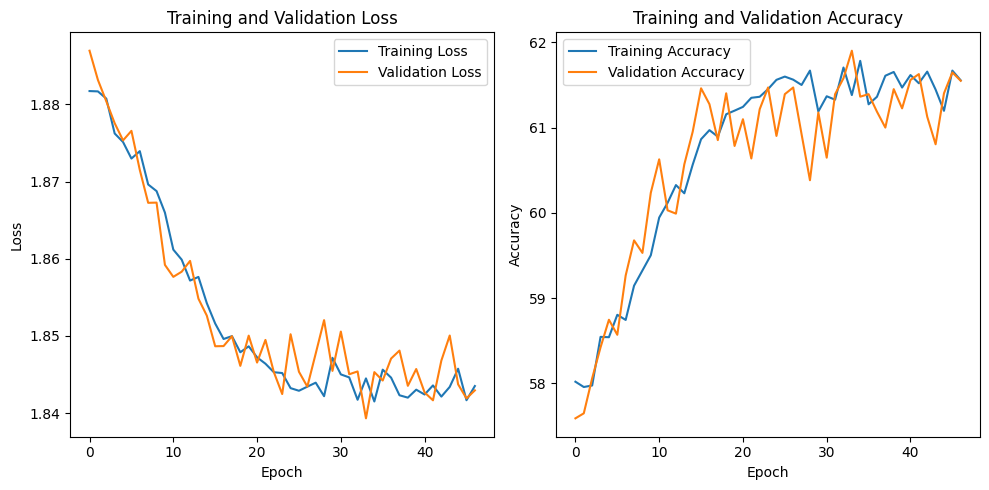

Epoch with the lowest validation loss: 34
Testing accuracy: 61.56


In [50]:
model_qat_trained = train_test_model_qat_warmup(model_qat, learning_rate, num_epochs)

In [51]:
#load weights from part 9a
PATH = f"/content/drive/MyDrive/UCSD Neuromorphic Computing Internship: Prof. Gert Cauwenberghs/EIC_NAS_Exploration/Part 9/pic_qat_part9ec.pth"
model_qat_trained.load_state_dict(torch.load(PATH, weights_only=True))
evaluate_model_custom_binary(model_qat_trained.eval(), test_loader)

61.51

In [ ]:
model_qat_trained.eval()
model_qat_trained(torch.rand(1,28,28))

In [ ]:
model_qat_converted = torch.ao.quantization.convert(model_qat_trained)
model_qat_converted.eval()

RuntimeError: Only Tensors created explicitly by the user (graph leaves) support the deepcopy protocol at the moment.  If you were attempting to deepcopy a module, this may be because of a torch.nn.utils.weight_norm usage, see https://github.com/pytorch/pytorch/pull/103001

In [ ]:
model_qat_converted(torch.rand(1,28,28))
evaluate_model_custom_binary(model_qat_converted, test_loader)

In [ ]:
#looking at activations

#hook function to store activations
def activation_hook(name):
    def hook(module, input, output):
        sample_activations = output[0][:10].tolist()  # Get first 10 activations
        print(f"Layer: {name} | Sample activations: {sample_activations}")
    return hook

#register hooks for the layers with binary activations
for name, module in model_qat.named_modules():
    if name in ('piclayer1', 'eiclayer1', 'eiclayer2', 'eiclayer3'):  # Only attach hooks to these layers
        module.register_forward_hook(activation_hook(name))


#create a sample input
sample_input = torch.randn(1, 1, 28, 28)  #batch size 1

# Forward pass
with torch.no_grad():
    model_qat(sample_input)

Layer: piclayer1 | Sample activations: [[[0.0, 2.6590850353240967, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0], [-0.0, -0.0, 0.0, -0.0, 0.0, -0.0, 0.0, -0.0, 2.6590850353240967, 2.6590850353240967, -0.0, -0.0, 0.0], [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, 0.0, -0.0, -0.0, 2.6590850353240967], [0.0, 2.6590850353240967, 2.6590850353240967, 2.6590850353240967, 0.0, -0.0, -0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -0.0], [2.6590850353240967, 2.6590850353240967, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, 2.6590850353240967, -0.0], [-0.0, -0.0, -0.0, 0.0, 2.6590850353240967, 0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0], [-0.0, 0.0, 0.0, 0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0], [0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, 2.6590850353240967, 0.0, 0.0, -0.0], [-0.0, -0.0, 0.0, -0.0, -0.0, 0.0, -0.0, 0.0, 0.0, 0.0, -0.0, -0.0, 0.0], [2.6590850353240967, -0.0, -0.0, -0.0, 2.6590850353240967, -0.0, -0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -0.0], [-0.0, 

In [ ]:
import random
def sample_quantized_weights(model):
  """Samples 100 weights from the quantized model and verifies their type."""
  model_qat = torch.ao.quantization.convert(model)  #ensure model is quantized

  print("Quantized Model Structure:", model_qat)
  model_qat.eval()

  #access the raw quantized weights (without parentheses)
  print("Raw Quantized Weights (fc1) - Quantized (qint8):", model_qat.layer0_col0.core1.fc1.weight())  #this should show quantized weights in their float representation
  print("Raw Quantized Weights (fc1) - Quantized (int8):", model_qat.layer0_col0.core1.fc1.weight().int_repr())  #this should show quantized weights in their integer representations

  #now dequantize and sample
  all_weights = torch.cat([
    model_qat.layer0_col0.core1.fc1.weight().dequantize().view(-1),
    model_qat.layer0_col0.core1.fc2.weight().dequantize().view(-1),
  ]).cpu().detach().numpy()

  all_weights_quant = torch.cat([
    model_qat.layer0_col0.core1.fc1.weight().int_repr().view(-1),
    model_qat.layer0_col0.core1.fc2.weight().int_repr().view(-1),
  ]).cpu().detach().numpy()


  sampled_weights = random.sample(list(all_weights), 100)
  sampled_quant_weights = random.sample(list(all_weights_quant), 100)
  print("Sampled Weights:", sampled_weights)
  print("Sampled Quantized Weights:", sampled_quant_weights)

#example usage:
sample_quantized_weights(model_qat_converted)

NameError: name 'model_qat_converted' is not defined

In [ ]:
evaluate_model_custom_binary(model_trained, test_loader)

84.71